Setup

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
import torchvision
import os
from matplotlib import pyplot as plt

In [56]:
torch.set_printoptions(sci_mode=False)
LR = 0.00001
EPOCHS = 100
BATCH_SIZE = 64
MODEL_PATH = "AutoencoderModel.pth"
DATA_PATH = "Training_Data"
TESTING_PATH = "Testing_Images"

In [3]:
class AutoencoderNetwork(nn.Module):
    def __init__(self):
        super(AutoencoderNetwork, self).__init__()

        """
        Conv2d hace convolución en 2 dimensiones #
        
        3 pasos del proceso convolucional
            * La imagen de entrada: Es una matriz de números, si es RGB son 3 matrizes superpuestas
            * El filtro o Kernel:   Es una matriz normalmente de 3x3 o 5x5 de pesos, estos serán ajustados durante el entreno
                Superposición:          Un filtro de 3x3 va a colocarce en la esquina superior izquierda
                Multiplicación:         El valor del pixel de debajo con el valor del filtro de arriba
                Suma:                   Se suman esos 9 resultados y se colocan en el primer pixel del mapa de caracteristicas
                Desplazamiento:         Mueves el filtro un pixel a la derecha y repites hasta acabar la fila,
                                        cuando acabes la fila bajas un pixel y empiezas en la izquierda otra vez

            * Mapa de caracteristicas: Es la nueva imagen resultante, contiene la información original simplificada
            * ReLU: Si un número es negativo lo convierte a 0, si no lo deja igual
        """

        self.encoder = nn.Sequential(
            
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=True),
            
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=True),

            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1,bias=True),

            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1, bias=True),

            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        return self.decoder(x)

    def encode(self, x):
        return self.encoder(x)

In [57]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)),
    torchvision.transforms.ToTensor()
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoencoderNetwork().to(device=device)
loss = None

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

Data loading

In [58]:
img_list = []

for _, _, files in os.walk(f"{DATA_PATH}"):
    for file in files:
        image = Image.open(f"{DATA_PATH}/{file}").convert("RGB")
        flat_tensor = transform(image)
        img_list.append(flat_tensor)

#torch.stack concatena (añade uno detrás de otro) tensores y devuelve un tensor
img_tensor = torch.stack(img_list)

dataset = TensorDataset(img_tensor)
dataloader = DataLoader(dataset=dataset, batch_size=BATCH_SIZE)

Training

In [59]:
loss_array = []
epoch_array = []

print("Training...")
model.train()
for epoch in range(EPOCHS):

    for i, batch in enumerate(dataloader):
        batch_x = batch[0].to(device)

        logits = model(batch_x)

        loss = criterion(logits, batch_x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"\nEpoch: {epoch}")
    print(f"Loss: {loss.item()}")
    if epoch % 1 == 0:
        loss_array.append(loss.item())
        epoch_array.append(epoch)

print("Training finished")
torch.save(model.state_dict(), MODEL_PATH)

Training...

Epoch: 0
Loss: 0.04523615911602974

Epoch: 1
Loss: 0.043123308569192886

Epoch: 2
Loss: 0.03961782157421112

Epoch: 3
Loss: 0.03436250239610672

Epoch: 4
Loss: 0.028482608497142792

Epoch: 5
Loss: 0.023159615695476532

Epoch: 6
Loss: 0.018839070573449135

Epoch: 7
Loss: 0.015585634857416153

Epoch: 8
Loss: 0.013036333955824375

Epoch: 9
Loss: 0.011278092861175537

Epoch: 10
Loss: 0.010034430772066116

Epoch: 11
Loss: 0.009121360257267952

Epoch: 12
Loss: 0.008419741876423359

Epoch: 13
Loss: 0.007861941121518612

Epoch: 14
Loss: 0.007399741094559431

Epoch: 15
Loss: 0.007016388699412346

Epoch: 16
Loss: 0.006694735959172249

Epoch: 17
Loss: 0.006416753865778446

Epoch: 18
Loss: 0.006167775020003319

Epoch: 19
Loss: 0.005947400350123644

Epoch: 20
Loss: 0.005731081590056419

Epoch: 21
Loss: 0.005541009828448296

Epoch: 22
Loss: 0.005361566785722971

Epoch: 23
Loss: 0.005184506997466087

Epoch: 24
Loss: 0.005012238398194313

Epoch: 25
Loss: 0.004845136776566505

Epoch: 26
Lo

Loading Model

In [ ]:
print("Loading model")
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True, map_location=device))

Evaluating

In [62]:
some_number = input("Name of file: ")
img_file_path = os.path.join(TESTING_PATH, f"{some_number}.jpg")

if os.path.exists(img_file_path):
    #.Unsqueeze(): Coge un tensor y le añade una columna de unos
    img_tensor_dev = transform(Image.open(img_file_path).convert("RGB")).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(img_tensor_dev)
        encoded_features = model.encode(img_tensor_dev)

    #.Squeeze():   Coge la columna de unos especificada en los parametros y la borra
    reconstructed_img = logits.squeeze(0).cpu()
    encoded_img = encoded_features.squeeze(0)[0].unsqueeze(0).cpu()

    torchvision.utils.save_image(reconstructed_img, f"Outputs/output{some_number}.jpg")
    torchvision.utils.save_image(encoded_img, f"Embeddeds/encoded{some_number}.jpg")

    print(f"\nDimensión Codificada (Latent): {encoded_features.size()}")
    print(f"Dimensión Entrada: {img_tensor_dev.size()}")
else:
    print(f"El archivo {img_file_path} no existe.")

if loss is not None:
    print(f"\nLoss Final: {loss.item()}")


Dimensión Codificada (Latent): torch.Size([1, 64, 16, 16])
Dimensión Entrada: torch.Size([1, 3, 64, 64])

Loss Final: 0.001489646965637803


Data Analizis

Text(0, 0.5, 'Loss')

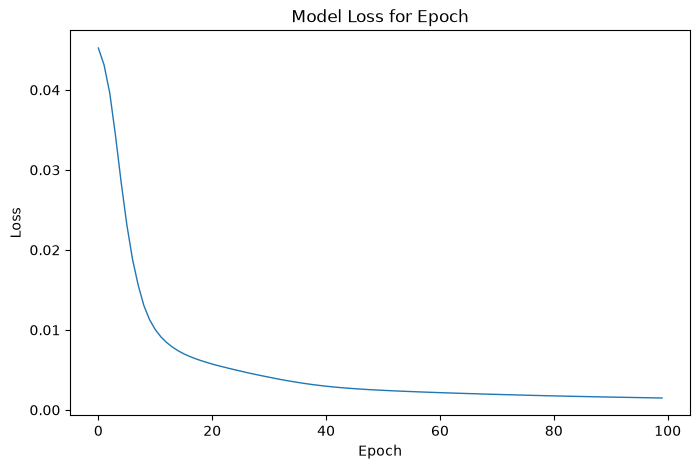

In [63]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(epoch_array, loss_array, label='Loss', linewidth=1)
ax.set_title('Model Loss for Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')